In [1]:
from ultralytics import YOLO
import torch

# 1. GPU 연결 확인 (사용 여부 체크)
device = '0' if torch.cuda.is_available() else 'cpu'
print(f"사용 가능한 장치: {torch.cuda.get_device_name(0) if device == '0' else 'CPU'}")

# 2. 모델 로드 (YOLOv8 Nano 모델 사용 - 빠르고 효율적임)
model = YOLO('../yolov8n.pt')

# 3. 모델 학습 시작
results = model.train(
    data='C:/Code/PythonProject/datasets/data.yaml',
    epochs=30,          # 50번은 너무 머니 30번으로 타협!
    imgsz=320,          # 인식률을 위해 해상도는 정석대로 640
    device='cpu',
    batch=4,            # CPU 메모리 부담을 줄이기 위해 낮게 설정
    name='cpu_train_320_dist',
    patience=5,          # 5번 동안 성능 향상 없으면 자동 종료
    workers = 0
)
print("✅ 학습이 완료되었습니다!")

사용 가능한 장치: CPU
Ultralytics 8.4.21  Python-3.13.11 torch-2.10.0+cpu CPU (13th Gen Intel Core i5-1335U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Code/PythonProject/datasets/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=../yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cpu_train_320_dist, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 


image 1/1 C:\Code\PythonProject\datasets\images\train\right_arrow_0005.jpg: 640x384 1 right, 95.4ms
Speed: 4.3ms preprocess, 95.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)


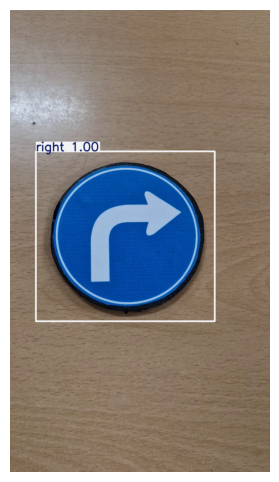

In [2]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
%matplotlib inline

# 모델 로드
model = YOLO('C:/Code/PythonProject/datasets/best.pt')

# 웹캠 대신 사진 한 장으로 먼저 테스트 (확인용)
img_path = 'C:/Code/PythonProject/datasets/images/train/right_arrow_0005.jpg' # 실제 있는 파일명으로 수정
#results = results = model.predict(img_path, imgsz=320, conf=0.5)
results = results = model.predict(img_path, imgsz=640, conf=0.5)

# 결과 시각화
annotated_frame = results[0].plot()
annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

# 노트북 셀에 바로 표시
plt.figure(figsize=(10, 6))
plt.imshow(annotated_frame_rgb)
plt.axis('off')
plt.show()

In [3]:
import cv2
from ultralytics import YOLO

# 1. 학습 완료된 최신 모델 로드
# runs 폴더 안의 최신 결과물 경로를 확인해서 넣어주세요.
model = YOLO('C:/Code/PythonProject/datasets/best.pt')

# 2. 웹캠 연결 (0번은 보통 노트북 내장 캠입니다)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("웹캠을 찾을 수 없습니다. 연결 상태를 확인해주세요.")
    exit()

print("--- 실시간 인식을 시작합니다 (종료하려면 'q' 키를 누르세요) ---")

while True:
    ret, frame = cap.read()
    if not ret:
        print("프레임을 가져올 수 없습니다.")
        break

    # 3. 모델 추론 (인식)
    # imgsz=320은 학습 때와 동일하게 맞춰 속도를 높였습니다.
    # results = model.predict(frame, imgsz=320, conf=0.5)
    results = model.predict(frame, imgsz=640, conf=0.5)

    # 4. 결과 시각화
    annotated_frame = results[0].plot()

    # 5. 화면 표시
    cv2.imshow("YOLOv8 Real-time Inspection", annotated_frame)

    # 키보드 'q'를 누르면 안전하게 종료
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 자원 해제
cap.release()
cv2.destroyAllWindows()

--- 실시간 인식을 시작합니다 (종료하려면 'q' 키를 누르세요) ---

0: 480x640 (no detections), 55.1ms
Speed: 2.2ms preprocess, 55.1ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 42.3ms
Speed: 2.3ms preprocess, 42.3ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 44.3ms
Speed: 1.6ms preprocess, 44.3ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 42.1ms
Speed: 1.4ms preprocess, 42.1ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 42.8ms
Speed: 1.5ms preprocess, 42.8ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 41.7ms
Speed: 1.5ms preprocess, 41.7ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 42.1ms
Speed: 1.0ms preprocess, 42.1ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections)